### Telecom Customer Churn Analysis
## Optimizing Retention Strategies Through Exploratory Data Analysis

---

## 1. Title & Introduction

### Project Overview
Customer retention is one of the primary growth drivers in the telecommunications industry. Acquiring a new customer costs significantly more than retaining an existing one. This capstone project focuses on analyzing customer demographics, account characteristics, and service usage patterns to uncover the root causes of customer attrition (churn).

### Dataset Description
The dataset used for this analysis is the **Telco Customer Churn dataset**, which contains information on 7,043 customers from a telecommunications company. Each row represents a unique customer, and the columns include:
* **Demographics:** Gender, senior citizen status, partner, and dependent status.
* **Account Information:** Tenure, contract type, payment method, paperless billing, monthly charges, and total charges.
* **Services Signed Up For:** Phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV/movies.
* **Target Variable:** `Churn` (Whether the customer left within the last month).

### Project Goal
The objective of this project is to clean, inspect, and explore the data to answer critical business questions regarding customer behavior. By identifying the key attributes that correlate strongly with churn, we aim to provide actionable, data-driven recommendations to help the business reduce customer churn rates.

## 2. Data Loading & Inspection

In this section, we load the required Python libraries and the raw dataset to perform an initial structural assessment.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 2.1 Data Cleaning 

In [19]:
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"]= df["TotalCharges"].fillna(df["TotalCharges"].mean())

# Question 1: What's the overall churn rate?

In [15]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

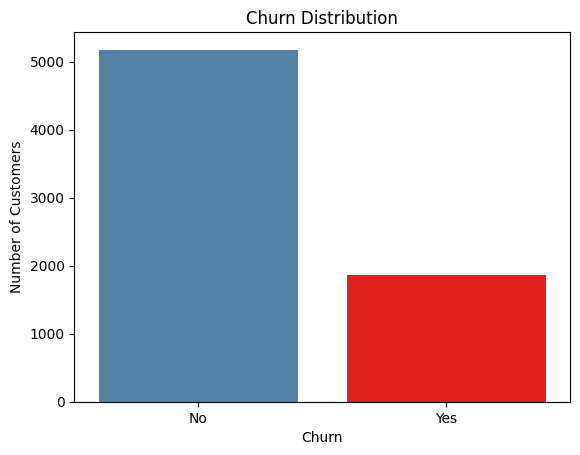

In [14]:
sns.countplot(data= df, x="Churn", hue="Churn", palette={"No": "steelblue", "Yes": "red"})
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Question 2: Does contract type affect churn?

In [16]:
df.groupby("Contract")["Churn"].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

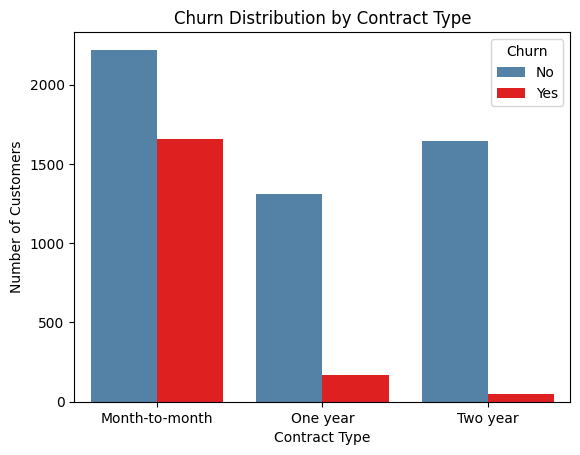

In [17]:
sns.countplot(data=df, x="Contract", hue="Churn", palette={"No": "steelblue", "Yes": "red"})
plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

# Question 3: Do churned customers pay more?

In [18]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_20172\2376273176.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette={"No": "steelblue", "Yes": "red"})


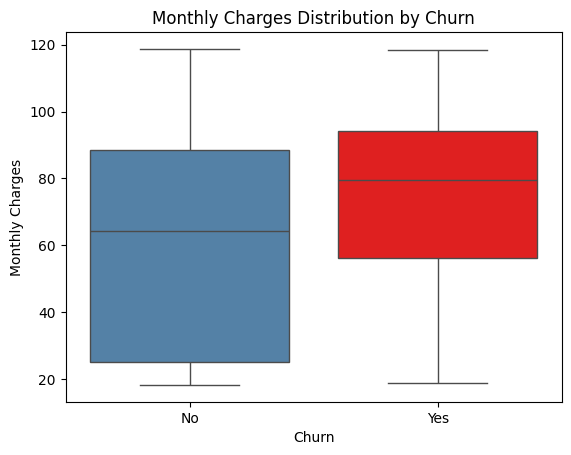

In [9]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette={"No": "steelblue", "Yes": "red"})
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

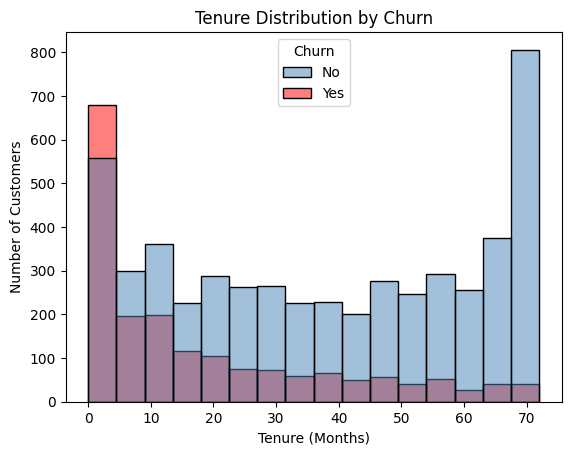

In [12]:
sns.histplot(data=df, x="tenure", hue="Churn", palette={"No": "steelblue", "Yes": "red"})
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

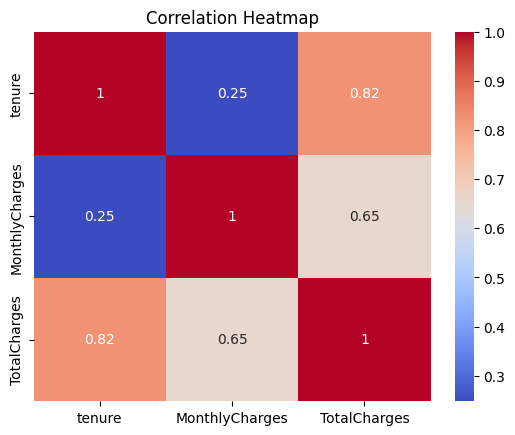

In [13]:
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Key Findings

1. **Overall churn is 26.54%**
   More than 1 in 4 customers leave.

2. **High-value customers are leaving**
   Customers who churn pay an average of $74.44/month, while those who stay 
   pay $61.27/month. The loss is hitting revenue harder than the headline 
   number suggests.

3. **Contract length drives churn**
   - Month-to-month: ~43% churn
   - 1-year contracts: ~11% churn
   - 2-year contracts: ~3% churn
   
   Longer contracts keep customers around. The month-to-month plan is the 
   main churn driver.

4. **Early tenure is the danger zone**
   Customers who churn are heavily concentrated in the first few months. 
   Once a customer passes the 6-month mark, retention improves dramatically.